Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital

**Métodos Computacionales — Reconstrucción y regularización en imágenes tomográficas**

# **Trabajo Práctico — Ejercicio N°2**

Antes de comenzar a resolver, importamos los módulos que utilizaremos en el desarrollo.

In [1]:
# Importación de módulos
import numpy as np
import matplotlib.pyplot as plt

Utilizaremos el fantoma del ejercicio anterior para simular una medición del modelo binario. Una
dirección discreta está determinada por el par ($\alpha$,$\beta$) y un desplazamiento entero $s$. El rayo correspon-
diente selecciona únicamente los píxeles cuyos centros satisfacen $\alpha i + \beta j = s$.

a) Implementar la función `mascara_rayo(n, direccion, s)`, que devuelva una matriz $M_r \in \{0,1\}^{n×n}$
con un $1$ en los píxeles seleccionados por el rayo $r$ y un $0$ en los restantes.

In [11]:
def mascara_rayo(n:int, direccion:tuple[int,int], s:int):
    res:np.ndarray = np.zeros(shape=(n,n), dtype=np.int8)
    for i in range(0,len(res)):
        for j in range(0,len(res)):
            if (direccion[0] * i) + (direccion[1] * j) == s:
                res[i][j] = 1
    return res

b) Visualizar las máscaras para las direcciones $(1,0)$, $(0,1)$, $(1,1)$, $(1,−1)$ y $(2,1)$, utilizando respectivamente los desplazamientos $s = 3,5,7,0,8$ (asumiendo $M^{8 \times 8}$, las dimensiones dadas por el ejercicio anterior).

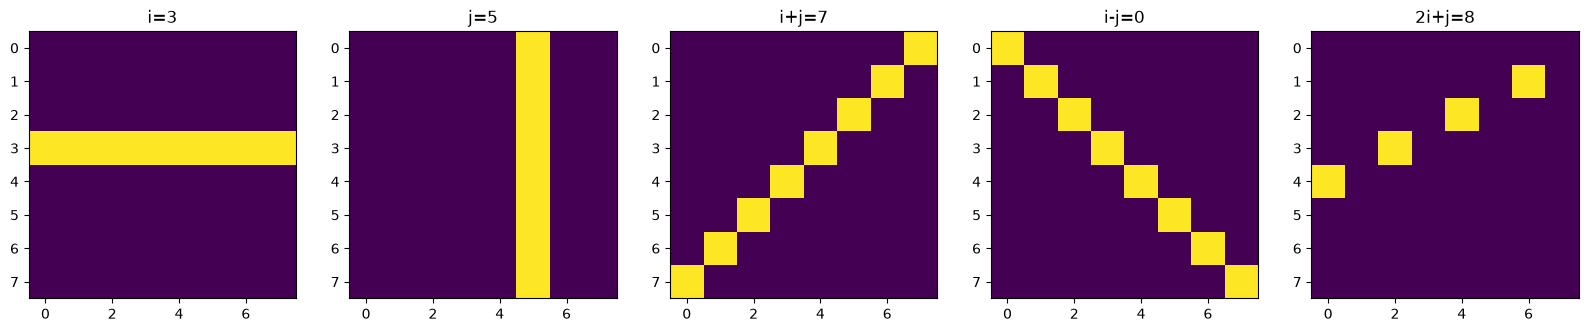

In [22]:
# Computamos las máscaras

res0 = mascara_rayo(8,(1,0),3)
res1 = mascara_rayo(8,(0,1),5)
res2 = mascara_rayo(8,(1,1),7)
res3 = mascara_rayo(8,(1,-1),0)
res4 = mascara_rayo(8,(2,1),8)

# Graficamos

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].set_title(f"i=3")
axes[0].imshow(res0)

axes[1].set_title(f"j=5")
axes[1].imshow(res1)

axes[2].set_title(f"i+j=7")
axes[2].imshow(res2)

axes[3].set_title(f"i-j=0")
axes[3].imshow(res3)

axes[4].set_title(f"2i+j=8")
axes[4].imshow(res4)


c) Para cada máscara, calcular la medición $b_r = \sum_{i,j}{ (M_r)_{ij} (X_{fantoma})_{ij} } $ mediante un producto componente a componente entre la máscara y el fantoma.


In [24]:
# Importamos X_fantoma del ejercicio anterior

X_fantoma:np.ndarray = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

# Computamos la medición para cada máscara

br0:np.float16 = np.sum(X_fantoma * res0)
br1:np.float16 = np.sum(X_fantoma * res1)
br2:np.float16 = np.sum(X_fantoma * res2)
br3:np.float16 = np.sum(X_fantoma * res3)
br4:np.float16 = np.sum(X_fantoma * res4)

print("br0: ",br0,", br1: ",br1,", br2: ",br2,", br3: ",br3, ", br4: ",br4)


br0:  2.3 , br1:  2.4 , br2:  1.2 , br3:  1.9000000000000001 , br4:  1.1


d) Explicar por qué dos rayos con orientaciones diferentes pueden producir el mismo valor de me-
dición aunque seleccionen distintos píxeles.

Dos rayos de diferente orientación pueden producir el mismo valor de medición $b_r$ aunque selecciones distintos píxeles debido al nivel de atenuación ante el rayo según la región afectada por la máscara de fantoma. Es decir, a pesar de que la máscara afecte un grupo diferente de píxeles, lo cierto es, que aún así el nivel de atenuación acumulado ante el impacto del rayo en ellos puede resultar ser el mismo.